<a href="https://colab.research.google.com/github/kyk-o/SecurityCamp/blob/main/AIAgent%E8%AD%B0%E8%AB%96%E5%9B%9E%E7%AD%941.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AIAgent議論

In [1]:
# 1. リポジトリをコピー
!git clone https://github.com/elith-co-jp/book-llm-agent.git
# 2. フォルダの中身を確認
!ls

Cloning into 'book-llm-agent'...
remote: Enumerating objects: 218, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 218 (delta 34), reused 25 (delta 25), pack-reused 142 (from 1)
Receiving objects: 100% (218/218), 837.69 KiB | 13.73 MiB/s, done.
Resolving deltas: 100% (104/104), done.
book-llm-agent	sample_data


In [2]:
# book-llm-agent フォルダに移動
%cd book-llm-agent

# 移動した後のフォルダ内にあるファイル一覧を表示
!ls

/content/book-llm-agent
llm_agent  notebooks  poetry.lock  pyproject.toml  README.md  tests


In [3]:
%cd /content/book-llm-agent

/content/book-llm-agent


In [4]:
!pip install -e /content/book-llm-agent

Obtaining file:///content/book-llm-agent
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


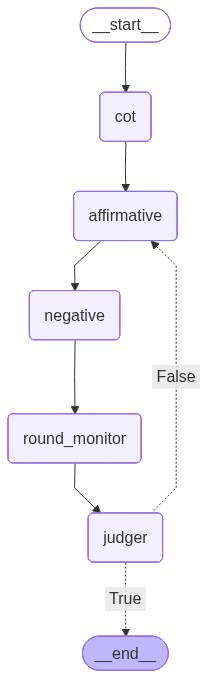

🎭 ディベート大会を開始します...

================================ Human Message =================================
Name: CoT_Assistant

以下のステップで論点を整理します。

### ステップ1: 状況の把握
- **時間**: 深夜3時47分にアラートが発報された。
- **内容**: 社内PC（192.168.10.44）から外部IP（203.0.113.82）への大量データ送信が検知された。
- **通信量**: 23分間で4.7 GBのデータ送信。
- **プロセス**: `sync_agent.exe`（AccountingSaaSの同期プログラム）による実行。
- **ユーザ**: yamada.keiko（経理部の社員）。

### ステップ2: 脅威インテリジェンスの照合
- **結果**: 
  - ベンダーAとBは問題なし。
  - ベンダーCは「情報窃取キャンペーンで観測されたIPを含むサブネット」との記録があった。
- **判定**: Confidence High（3社中1社がヒット）。

### ステップ3: EDRによる端末確認
- **プロセスのデジタル署名**: 有効（AccountingSaaS Inc.から発行）。
- **親プロセス**: 正規のWindowsサービス（services.exe）。
- **実行権限**: SYSTEM権限。
- **直近の異常**: なし。

### ステップ4: AIエージェントの自動対応
- **対応内容**:
  - PC（192.168.10.44）のネットワーク接続を遮断。
  - Active Directoryのアカウント yamada.keiko を一時停止。
  - インシデントチケット #2891 を自動で起票。
- **総合判定**: Confidence 87%。

### ステップ5: SOCアナリストの調査結果
- **yamada.keiko**: 経理部の社員で、月次決算作業中。
- **sync_agent.exe**: 会社契約の公式バックアッププログラム。
- **送信先IP**: 203.0.113.82は会計SaaSのデータセンターのIP（ホワイト

In [1]:
import os
import functools
from typing import Annotated, TypedDict
from google.colab import userdata
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from IPython.display import display, Image

# 1. APIキーの設定
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

# 2. モデルの準備 (審判は賢い4o、選手は機敏な4o-mini)
llm_judge = ChatOpenAI(model="gpt-4o", temperature=0)
llm_player = ChatOpenAI(model="gpt-4o-mini", temperature=0.7) # 議論を活性化させるため少し温度を上げます

# 3. 状態(State)の定義
class DebateState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    debate_topic: str
    judged: bool
    round: int

# --- 4. エージェント関数の定義 ---

# 導入エージェント (CoT)
def cot_agent(state: DebateState):
    system_prompt = SystemMessage(content=f"議題「{state['debate_topic']}」について、論点をステップバイステップで整理してください。")
    res = llm_player.invoke([system_prompt])
    message = HumanMessage(content=res.content, name="CoT_Assistant")
    return {"messages": [message]}

# ディベーター関数
def debater(state: DebateState, name: str, position: str):
    system_prompt = SystemMessage(content=(
        f"あなたはディベーターです。議題：{state['debate_topic']}\n"
        f"立ち位置：{position}\n"
        "相手の主張がある場合は、論理的に反論しつつ自分の主張を述べてください。簡潔に！"
    ))
    res = llm_player.invoke([system_prompt] + state["messages"])
    message = HumanMessage(content=res.content, name=name)
    return {"messages": [message]}

# 肯定側と否定側の設定
affirmative_debater = functools.partial(debater, name="Affirmative", position="肯定派。メリットを強調してください。")
negative_debater = functools.partial(debater, name="Negative", position="否定派。リスクやデメリットを強調してください。")

# 審判（Judger）
class JudgeSchema(BaseModel):
    judged: bool = Field(..., description="勝敗がついたかどうか")
    answer: str = Field(..., description="判定結果とその理由")

def judger(state: DebateState):
    system_prompt = SystemMessage(content=(
        f"あなたはディベートの審判です。議題：{state['debate_topic']}\n"
        "これまでの議論を評価し、決着がついたか判断してください。"
    ))
    llm_with_format = llm_judge.with_structured_output(JudgeSchema)
    res = llm_with_format.invoke([system_prompt] + state["messages"])

    messages = []
    if res.judged:
        messages.append(HumanMessage(content=f"【審判の判決】\n{res.answer}", name="Judge"))

    return {"messages": messages, "judged": res.judged}

# ラウンド管理
def round_monitor(state: DebateState, max_round: int):
    new_round = state["round"] + 1
    if new_round >= max_round:
        return {"round": new_round, "messages": [HumanMessage(content="最終ラウンドです。審判は必ず勝敗を決してください。")]}
    return {"round": new_round}

# --- 5. グラフの構築 ---
builder = StateGraph(DebateState)

builder.add_node("cot", cot_agent)
builder.add_node("affirmative", affirmative_debater)
builder.add_node("negative", negative_debater)
builder.add_node("round_monitor", functools.partial(round_monitor, max_round=3))
builder.add_node("judger", judger)

# エッジを繋ぐ
builder.add_edge(START, "cot")
builder.add_edge("cot", "affirmative")
builder.add_edge("affirmative", "negative")
builder.add_edge("negative", "round_monitor")
builder.add_edge("round_monitor", "judger")

# 審判の判定による条件分岐
builder.add_conditional_edges(
    "judger",
    lambda state: state["judged"],
    {True: END, False: "affirmative"}
)

graph = builder.compile()

# --- 6. 実行 ---
display(Image(graph.get_graph().draw_mermaid_png()))

inputs = {
    "messages": [],
    "debate_topic": r"""======================================================================================================================================================================================================
# 問１
## はじめに読んでほしいこと
企業のセキュリティ部門（SOC）では最近、アラートの量が多すぎて人間だけでは対応しきれないため、AIエージェントに検知から対応までを自動で行えるようにしたいと考えています。

この設問では、そのようなAIエージェントが実際に動いた場面のログを読んで、「AIの判断は適切だったか」を考えてもらいます。

## 状況説明
ある会社のSOCに、AIエージェントが導入されて3ヶ月が経ちます。このエージェントは

* 社内ネットワークの通信を常時監視し
* 不審と判断した場合は自動でPCの通信を止めたりアカウントを無効化したりできる
* 対応後にSOCの担当者へメールで通知する

という仕組みで動いています。担当者は対応後に知らされる設計です。

## ログの解読
以下のログは、AIエージェントが深夜に何かを検知してから、翌朝に担当者が調査するまでの記録です。時系列順に並んでいます。各ブロックが「エージェントが何をしたか／調べたか」を示しています。

```
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
【STEP 1】 深夜3時47分 ─ SIEMがアラートを発報
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  検知内容 : 社内PC（192.168.10.44）から外部IPへの大量データ送信
  送信先   : 203.0.113.82（社外）
  通信量   : 23分間で4.7 GB（HTTPS）
  実行中の
  プロセス : C:\Program Files\AccountingSaaS\sync_agent.exe
             ↑「AccountingSaaS」というソフトウェアの同期プログラム
  操作ユーザ: yamada.keiko@example.com
  ヒットしたルール   : ""1GB以上の外部送信を検知""

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
【STEP 2】 深夜3時47分 ─ 脅威インテリジェンスで送信先IPを照合
           ※脅威インテリジェンス＝既知の悪性IPや攻撃者情報のデータベース
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  照合対象 : 203.0.113.82
  ベンダーA : 問題なし
  ベンダーB : 問題なし
  ベンダーC : 「2024年9月に情報窃取キャンペーンで観測されたIPを含むサブネット」という記録あり  ← ★ここだけがヒット
  判定     : Confidence High（3社中1社がヒット）

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
【STEP 3】 深夜3時47分 ─ EDRで端末を確認
           ※EDR＝PCの上で何のプロセスが動いているかを監視するツール
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  プロセスのデジタル署名: 有効（発行元：AccountingSaaS Inc.）
   ↑正規のソフトウェアとして認証されている

  親プロセス  : services.exe（Windowsの正規サービス起動プロセス）
  実行権限    : SYSTEM権限
  直近の異常  : なし

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
【STEP 4】 深夜3時47分 ─ エージェントが自動対応を実行
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  実行した対応:
    → PC（192.168.10.44）のネットワーク接続を遮断
    → Active Directoryのアカウント yamada.keiko を一時停止
       ↑社内の認証システム。停止するとPC・メール・社内システムすべてにログイン不可
    → インシデントチケット #2891 を自動起票
  総合判定   : Confidence 87%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
【STEP 5】 翌朝8時30分 ─ 出社したSOCアナリストが調査した結果
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ・yamada.keiko は経理部の社員。前日から月次決算の作業をしていた
  ・sync_agent.exe は会社が契約しているクラウド会計SaaSの公式バックアッププログラムだった
  ・送信先の 203.0.113.82 はその会計SaaSのデータセンターのIPだった
    （社内のホワイトリスト＝許可リストへの登録が漏れていた）
  ・ベンダーCがヒットした理由：2024年9月のレポートに「このIPと同じサブネット（/24）の中に悪性IPがあった」という記述があっただけで、このIPアドレスそのものへの評価ではなかった

・対応の結果：復旧作業に2.5時間かかり、月次決算の提出が4時間遅延した
""",
    "judged": False,
    "round": 0,
}

print("🎭 ディベート大会を開始します...\n")
for event in graph.stream(inputs):
    for value in event.values():
        if "messages" in value and value["messages"]:
            value["messages"][-1].pretty_print()
